# R1 Data Pipeline — Data Validity Checks
Exercises `EyeGazeDataModule`/`EyeGazeDataset` against the real sample bundle: split sizes, validity coverage, target unit-norm, visual spot-check, and train/val subject-leakage check.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import matplotlib.pyplot as plt

from evedataset import EveBundle
from eyenet.dataset import EyeGazeDataModule
from eyenet.sampling import build_sample_index
from eyenet.splits import assign_splits, make_train_val_split

EVEDATASET_REPO = Path.cwd().parent.parent / "eve_shared" / "EveDataset"
BUNDLE_DIR = EVEDATASET_REPO / "bundle"
CROPS_ROOT = EVEDATASET_REPO / "eve_out"

bundle = EveBundle.load(BUNDLE_DIR)
bundle.samples_df.head()

,exp_key,subject,stimulus_name,split,valid,stimulus_path
0,train13_step027,train13,MIT-i2130236527,train,True,stimuli/train13_step027.png
1,train13_step021,train13,MIT-i2248598896,train,True,stimuli/train13_step021.png
2,train13_step062,train13,MIT-i1162738677,train,True,stimuli/train13_step062.png
3,train13_step022,train13,MIT-i102423191,train,True,stimuli/train13_step022.png
4,train13_step047,train13,MIT-i2300299195,train,True,stimuli/train13_step047.png


## Split sizes

In [2]:
dm = EyeGazeDataModule(bundle, CROPS_ROOT, {"seed": 0, "val_fraction": 0.2}, num_workers=0)
dm.setup()

subject_of = dict(zip(bundle.samples_df["exp_key"], bundle.samples_df["subject"]))

eve_val_subjects = set(bundle.samples_df.loc[bundle.samples_df["split"] == "val", "subject"])
eve_train_subjects = set(bundle.samples_df.loc[bundle.samples_df["split"] == "train", "subject"])

our_train_subjects = {subject_of[ek] for ek in dm.train_ds._index["exp_key"]}
our_val_subjects = {subject_of[ek] for ek in dm.val_ds._index["exp_key"]}
our_test_subjects = {subject_of[ek] for ek in dm.test_ds._index["exp_key"]}

print(f"EVE split=='val' subjects:   {len(eve_val_subjects)}")
print(f"our 'test' subjects:        {len(our_test_subjects)}")
assert our_test_subjects == eve_val_subjects, "our test split must equal EVE's val subjects exactly"

print(f"EVE split=='train' subjects: {len(eve_train_subjects)}")
print(f"our train+val subjects:      {len(our_train_subjects | our_val_subjects)}")
assert (our_train_subjects | our_val_subjects) <= eve_train_subjects

EVE split=='val' subjects:   5
our 'test' subjects:        5
EVE split=='train' subjects: 39
our train+val subjects:      39


## Coverage rate — validity gate over a sample of exp_keys

In [3]:
sample_exp_keys = [ek for ek in bundle.samples_df["exp_key"] if bundle.has_gaze_norm(ek) and bundle.has_face_crops(ek)][:20]
index = build_sample_index(bundle, sample_exp_keys)

total_slots = len(sample_exp_keys) * 90 * 2
coverage = len(index) / total_slots
print(f"exp_keys sampled: {len(sample_exp_keys)}, valid (frame,patch) rows: {len(index)}/{total_slots} = {coverage:.1%}")
assert 0 < coverage < 1, "coverage gate should be discriminating, not 0% or silently 100%"

exp_keys sampled: 20, valid (frame,patch) rows: 3046/3600 = 84.6%


## Target unit-norm check

In [11]:
rng = np.random.default_rng(0)
ds = dm.train_ds
idxs = rng.integers(0, len(ds), size=min(100, len(ds)))
norms = [np.linalg.norm(ds[int(i)][1].numpy()) for i in idxs]
assert all(abs(n - 1.0) <= 1e-4 for n in norms)

## Visual spot-check — eye crops with gaze-target arrow overlay

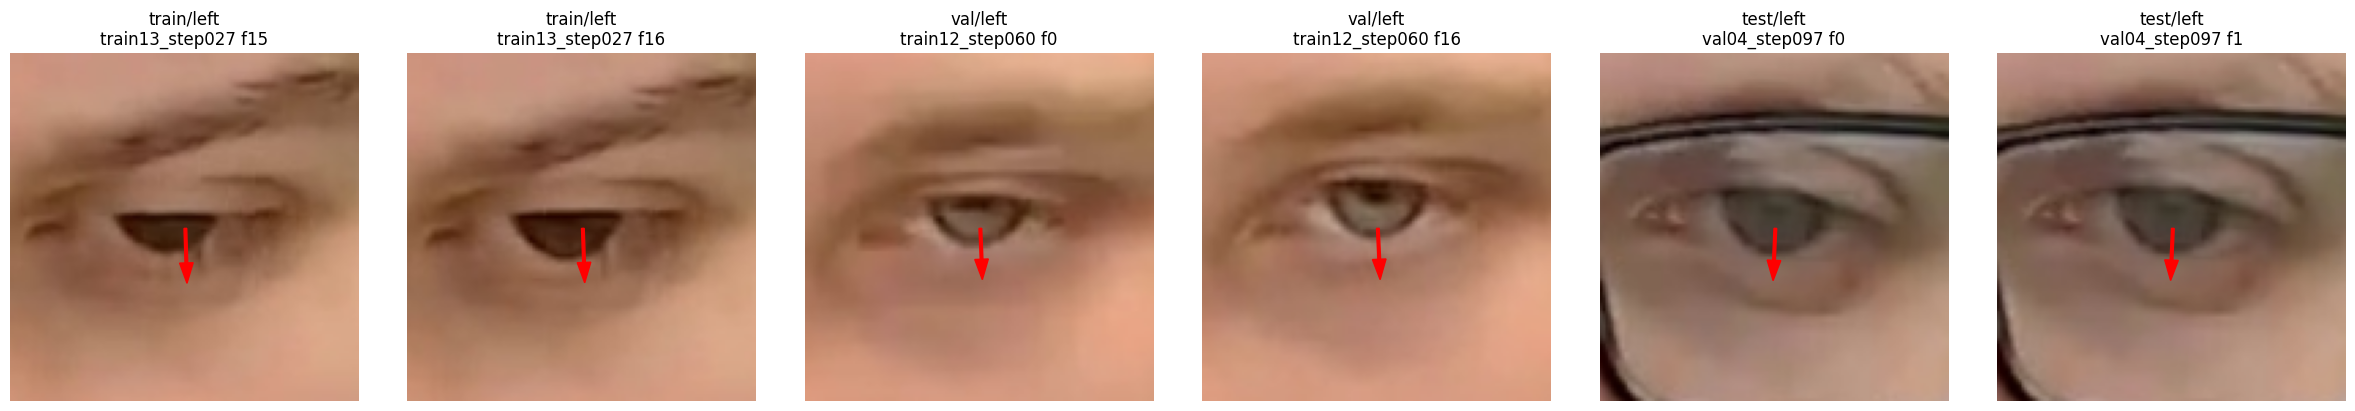

In [5]:
_MEAN = np.array([0.485, 0.456, 0.406])
_STD = np.array([0.229, 0.224, 0.225])

def unnormalize(img_chw):
    img = img_chw.numpy().transpose(1, 2, 0)
    img = img * _STD + _MEAN
    return np.clip(img, 0, 1)

samples = []
for split_name, ds in [("train", dm.train_ds), ("val", dm.val_ds), ("test", dm.test_ds)]:
    picked = 0
    for i in range(len(ds)):
        _, _, _, _, patch = ds[i]
        samples.append((split_name, ds, i))
        picked += 1
        if picked >= 2:
            break

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
for ax, (split_name, ds, i) in zip(axes, samples):
    image, target, exp_key, frame, patch = ds[i]
    img = unnormalize(image)
    ax.imshow(img)
    cx, cy = 64, 64
    dx, dy = target.numpy()[0] * 40, target.numpy()[1] * 40
    ax.arrow(cx, cy, dx, dy, color="red", width=1, head_width=5)
    ax.set_title(f"{split_name}/{patch}\n{exp_key} f{frame}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## No frame/exp_key leakage across our train/val/test

In [6]:
assert our_train_subjects.isdisjoint(our_val_subjects)
assert our_train_subjects.isdisjoint(our_test_subjects)
assert our_val_subjects.isdisjoint(our_test_subjects)
print("no subject overlap between train/val/test")

no subject overlap between train/val/test
